<div class="alert alert-block alert-info">
Singapore Management University<br>
CS105 Statistical Thinking for Data Science, 2025/26 Term 2
</div>

# CS105 Group Project Submission (Final)

-----
Provide your team details, including section, team number, team members, and the name of the dataset. 
Complete all of the following sections. For any part requiring code to derive your answers, please create a code cell immediately below your response and run the code.
To edit any markdown cell, double click the cell; after editing, execute the markdown cell to collapse it.

Include both Part I and Part II to produce a self-contained notebook. You may fine-tune Part I codes and/or findings based on feedback received on Part I submission.
<br>
-----

## Declaration

<span style="color:red">By submitting this notebook, we declare that **no part of this submission is generated by any AI tool**. We understand that AI-generated submissions will be considered as plagiarism, and just like other plagirisum cases, disciplinary actions will be imposed.</span>

#### Section: 
#### Team: 
#### Members:
1. 
2. 
3. 
4. 
5. 

#### Dataset: 

## Part I: Exploratory Data Analysis (EDA) [8% of final grade]

### 1. Overview of dataset [15% of Part I]

**a.** Summarise the background of the dataset [limited to 50 words]

The dataset contains housing related information from a census survey. Each row represents a town, with attributes like environmental conditions, accessibility, and socio-economic factors. Price is the key variable of interest. The dataset consists of 506 rows and 14 columns, which summarises housing characteristics across different locations.

**b.** State the size of the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# load dataframe
df = pd.read_csv('housing.csv')
n_rows, n_cols = df.shape
print(f"Number of rows is {n_rows}.")
print(f"Number of columns is {n_cols}.")

Number of rows is 506.
Number of columns is 14.


**c.** For each variable, describe what it represents and its data type (numerical or categorical)

In [2]:
pd.set_option('display.max_colwidth', None)
data = {
    "Variable": [
        "ID", "Crime_Rate", "Residential_Area", "Non_Retail", "River",
        "Pollutants", "Rooms", "Old_Housing", "Distance_Office",
        "Highway_Access", "Tax_Rate", "Student_Teacher_Ratio",
        "Low_Income", "Price"
    ],
    
    "Description": [
        "Identification Number",
        "Crime rate per capita",
        "Percentage of residential area greater than 25000 square feet",
        "Percentage of business areas used for non-retail",
        "Near bridge",
        "Concentration of pollutants (parts per 10 million)",
        "Number of rooms per unit",
        "Percentage of units built before second world war",
        "Weighted distances to major office areas",
        "Accessibility to major highways",
        "Property tax rate per $10,000",
        "Student to teacher ratio",
        "Percentage of low income households",
        "Median price of homes (in $1000s)"
    ],
    
    "Type": [
        "categorical", "categorical", "categorical", "numerical", "categorical",
        "numerical", "numerical", "numerical", "numerical", "categorical",
        "numerical", "numerical", "numerical", "numerical"
    ]
}
data_df = pd.DataFrame(data)
data_df

,Variable,Description,Type
0,ID,Identification Number,categorical
1,Crime_Rate,Crime rate per capita,categorical
2,Residential_Area,Percentage of residential area greater than 25000 square feet,categorical
3,Non_Retail,Percentage of business areas used for non-retail,numerical
4,River,Near bridge,categorical
5,Pollutants,Concentration of pollutants (parts per 10 million),numerical
6,Rooms,Number of rooms per unit,numerical
7,Old_Housing,Percentage of units built before second world war,numerical
8,Distance_Office,Weighted distances to major office areas,numerical
9,Highway_Access,Accessibility to major highways,categorical


### 2. Data pre-processing [35% of Part I]

**a.** For each variable, determine the percentage of missing data. For any column with missing data, describe how you resolve the issue. Clearly state any assumption you made.

In [3]:
n_rows, n_cols = df.shape
print("Percentage of Data Missing")
1.0 - df.count() / n_rows

Percentage of Data Missing


ID                       0.000000
Crime_Rate               0.045455
Residential_Area         0.000000
Non_Retail               0.000000
River                    0.000000
Pollutants               0.000000
Rooms                    0.000000
Old_Housing              0.000000
Distance_Office          0.000000
Highway_Access           0.000000
Tax_Rate                 0.000000
Student_Teacher_Ratio    0.000000
Low_Income               0.043478
Price                    0.000000
dtype: float64

This shows that only Crime_Rate and Low_Income have missing data of 4.55% and 4.35% respectively.

For Crime_Rate, we impute the column using the mode of Crime_Rate across the dataset. 

In [4]:
crime_rate_mode = df.Crime_Rate.mode()[0] 
df.Crime_Rate.value_counts()  

Crime_Rate
Low         367
Moderate    100
High         16
Name: count, dtype: int64

The mode of Crime_Rate is "Low". So we assume that rows without Crime_Rate data has a Low crime rate.

In [5]:
df['Crime_Rate'] = df['Crime_Rate'].fillna(crime_rate_mode)
df.count()

ID                       506
Crime_Rate               506
Residential_Area         506
Non_Retail               506
River                    506
Pollutants               506
Rooms                    506
Old_Housing              506
Distance_Office          506
Highway_Access           506
Tax_Rate                 506
Student_Teacher_Ratio    506
Low_Income               484
Price                    506
dtype: int64

We decided to drop the rows without income data as it is hard to determine income of household.

In [6]:
# drop low income household
df.dropna(inplace=True)
df.count()

ID                       484
Crime_Rate               484
Residential_Area         484
Non_Retail               484
River                    484
Pollutants               484
Rooms                    484
Old_Housing              484
Distance_Office          484
Highway_Access           484
Tax_Rate                 484
Student_Teacher_Ratio    484
Low_Income               484
Price                    484
dtype: int64

**b.** For each variable, identify outliers (if any) and describe how you resolve the issue. Clearly state any assumption you made.

To find outliers, we do a boxplot for numerical data. Any value that falls outside the boxplot is considered outlier.

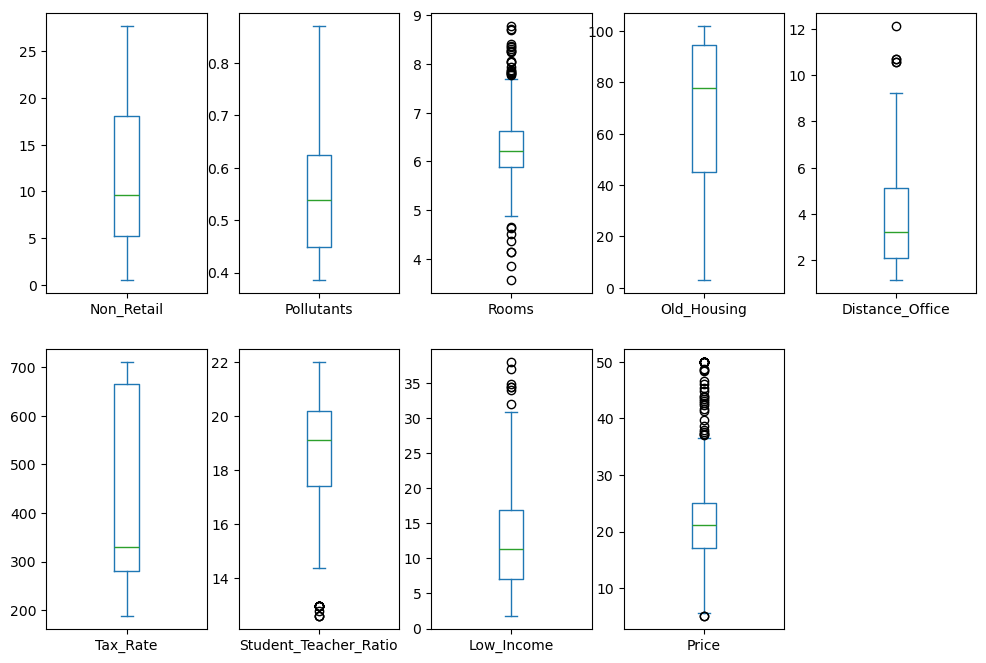

In [7]:

df_numerics = df[["Non_Retail","Pollutants","Rooms","Old_Housing","Distance_Office","Tax_Rate","Student_Teacher_Ratio", "Low_Income", "Price"]]
df_numerics.plot(kind='box',  subplots=True, layout=(2, 5), figsize=(12, 8))
plt.show()

**c.** For categorical variables, perform the necessary encoding.

For all categorical data ("River", "Crime_Rate", "Highway_Access" and "Residential_Area"), we perfromed ordnal encoding to encode them.

In [8]:
# encoding "River" to "0" (Near) and "1" (Far)
encoding = {"Near":0, "Far":1}
df["River_Encoded"] = df["River"].map(encoding)

# encoding "Crime_Rate" and "Highway_Access" to "0" (Low), "1" (Moderate) and "2" (High)
encoding = {"Low": 0, "Moderate":1, "High": 2}
df["Crime_Rate_Encoded"] = df["Crime_Rate"].map(encoding)
df["Highway_Access_Encoded"] = df["Highway_Access"].map(encoding)

# encoding "Residential_Area" to "0" (Very Low), "1" (Low), "2" (Moderate), "3" (High), "4" (Very High)
encoding = {"Very Low": 0, "Low": 1, "Moderate": 2, "High": 3, "Very High": 4}
df["Residential_Area_Encoded"] = df["Residential_Area"].map(encoding)

df

,ID,Crime_Rate,Residential_Area,Non_Retail,River,Pollutants,Rooms,Old_Housing,Distance_Office,Highway_Access,Tax_Rate,Student_Teacher_Ratio,Low_Income,Price,River_Encoded,Crime_Rate_Encoded,Highway_Access_Encoded,Residential_Area_Encoded
0,1,Low,Very Low,2.31,Far,0.538,6.575,65.2,4.0900,Low,296,15.3,4.98,24.0,1,0,0,0
1,2,Low,Very Low,7.07,Far,0.469,6.421,78.9,4.9671,Low,242,17.8,9.14,21.6,1,0,0,0
2,3,Low,Very Low,7.07,Far,0.469,7.185,61.1,4.9671,Low,242,17.8,4.03,34.7,1,0,0,0
3,4,Low,Very Low,2.18,Far,0.458,6.998,45.8,6.0622,Low,222,18.7,2.94,33.4,1,0,0,0
4,5,Low,Very Low,2.18,Far,0.458,7.147,54.2,6.0622,Low,222,18.7,5.33,36.2,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,502,Low,Very Low,11.93,Far,0.573,6.593,69.1,2.4786,Low,273,21.0,9.67,22.4,1,0,0,0
502,503,Low,Very Low,11.93,Far,0.573,6.120,76.7,2.2875,Low,282,21.0,9.08,20.6,1,0,0,0
503,504,Low,Very Low,11.93,Far,0.573,6.976,91.0,2.1675,Low,273,21.0,5.64,23.9,1,0,0,0
504,505,Low,Very Low,11.93,Far,0.573,6.794,89.3,2.3889,Low,273,21.0,6.48,22.0,1,0,0,0


### 3.	Exploratory analysis and visualization [50% of Part I]

**a.** For each variable, provide relevant summary statistics

In [9]:
for col in range(14):

    column = df.iloc[:, col]

    print("Variable:", df.columns[col])
    if col == 0:
        print("Type: Categorical")
        print("Unique values:", column.nunique())
        print("\n")
        continue

    if column.dtype != "object":
        print("Type: Numerical")
        print("Count:", column.count())
        print("Mean:", column.mean())
        print("Median:", column.median())
        print("Min:", column.min())
        print("Max:", column.max())
        print("Standard Deviation:", column.std())
    
    else:
        print("Type: Categorical")
        print("Unique values:", column.nunique())
        print("Most frequent values:")
        print(column.value_counts().head(5))

    print("\n")
    

Variable: ID
Type: Categorical
Unique values: 484


Variable: Crime_Rate
Type: Categorical
Unique values: 3
Most frequent values:
Crime_Rate
Low         374
Moderate     96
High         14
Name: count, dtype: int64


Variable: Residential_Area
Type: Categorical
Unique values: 5
Most frequent values:
Residential_Area
Very Low     366
Low           62
Very High     27
Moderate      19
High          10
Name: count, dtype: int64


Variable: Non_Retail
Type: Numerical
Count: 484
Mean: 11.073946280991734
Median: 9.6
Min: 0.46
Max: 27.74
Standard Deviation: 6.797627914514646


Variable: River
Type: Categorical
Unique values: 2
Most frequent values:
River
Far     453
Near     31
Name: count, dtype: int64


Variable: Pollutants
Type: Numerical
Count: 484
Mean: 0.5548421487603306
Median: 0.538
Min: 0.385
Max: 0.871
Standard Deviation: 0.11575030973280691


Variable: Rooms
Type: Numerical
Count: 484
Mean: 6.288311983471074
Median: 6.211
Min: 3.561
Max: 8.78
Standard Deviation: 0.7042761461546418


**b.** For each variable, provide an appropriate visualisation depicting the distribution of its values, and summarize any key observation(s) you made.

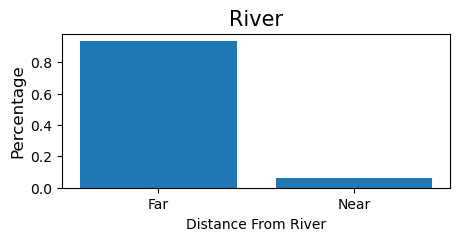

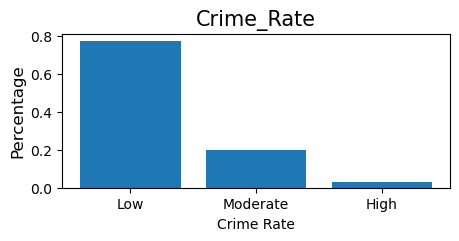

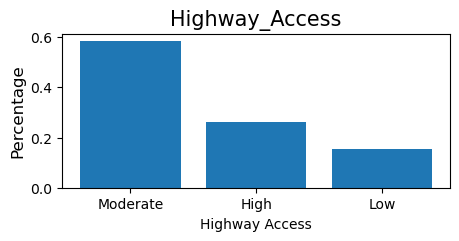

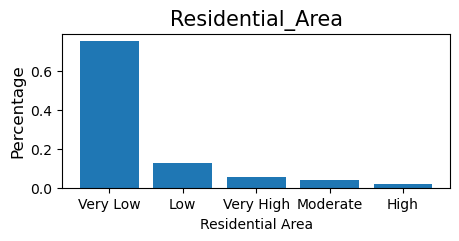

In [10]:
df["River"] = df["River"].astype(str)
data = df["River"].value_counts(normalize=True)

xs = data.index
ys = data

plt.figure(figsize=(5,2))
plt.bar(xs, ys)
plt.title("River", fontsize=15)
plt.xlabel("Distance From River")
plt.ylabel("Percentage", fontsize=12)
plt.show()

df["Crime_Rate"] = df["Crime_Rate"].astype(str)
data = df["Crime_Rate"].value_counts(normalize=True)

xs = data.index
ys = data

plt.figure(figsize=(5,2))
plt.bar(xs, ys)
plt.title("Crime_Rate", fontsize=15)
plt.xlabel("Crime Rate")
plt.ylabel("Percentage", fontsize=12)
plt.show()

df["Highway_Access"] = df["Highway_Access"].astype(str)
data = df["Highway_Access"].value_counts(normalize=True)

xs = data.index
ys = data

plt.figure(figsize=(5,2))
plt.bar(xs, ys)
plt.title("Highway_Access", fontsize=15)
plt.xlabel("Highway Access")
plt.ylabel("Percentage", fontsize=12)
plt.show()

df["Residential_Area"] = df["Residential_Area"].astype(str)    
data = df["Residential_Area"].value_counts(normalize=True)

xs = data.index
ys = data

plt.figure(figsize=(5,2))
plt.bar(xs, ys)
plt.title("Residential_Area", fontsize=15)
plt.xlabel("Residential Area")
plt.ylabel("Percentage", fontsize=12)
plt.show()


**River**: Majority of towns are located far from a river (94.2%)
There is a large imbalance between towns that are located far from a river and towns that are located near a river.

**Crime_Rate**: Majority of towns have a low crime rate (77.7%).
There is a small minority of towns that have a high crime rate (1.70%).

**Highway_Access**: Most towns have moderate highway access (59.2%).
There is a minority of towns that have a low access to highway(15.0%).


**Residential_Area**: A large majority towns have a very low percentage of residential area greater than 25000 square feet (79.1%).
There is a large imblance of towns that have a very low residential area greaer than 25000 square feet than those that do not.

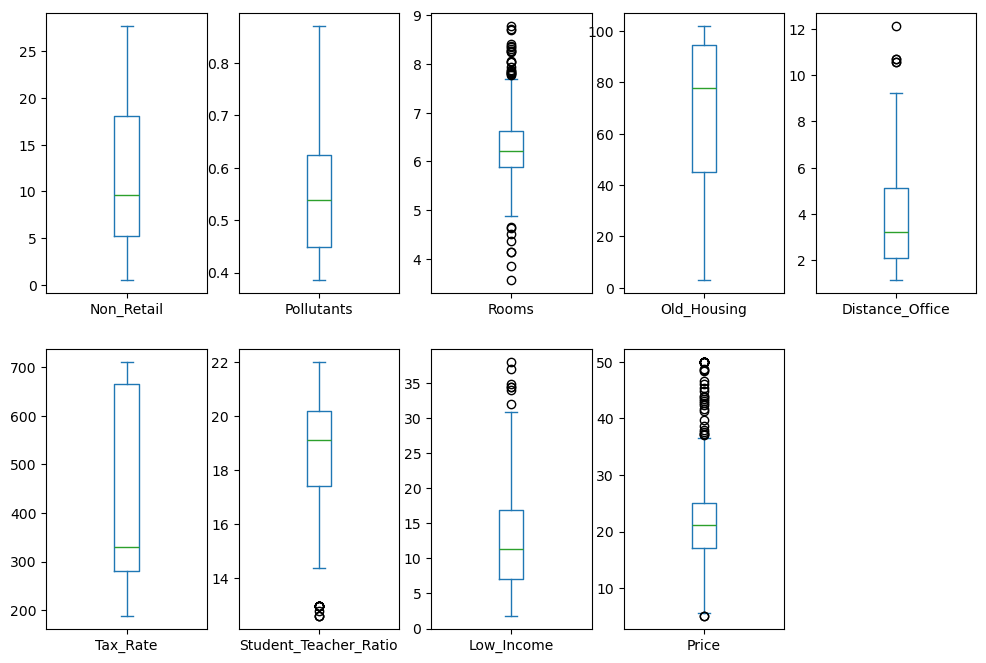

In [11]:
df_numerics = df[["Non_Retail","Pollutants","Rooms","Old_Housing","Distance_Office","Tax_Rate","Student_Teacher_Ratio", "Low_Income", "Price"]]
df_numerics.plot(kind='box',  subplots=True, layout=(2, 5), figsize=(12, 8))
plt.show()

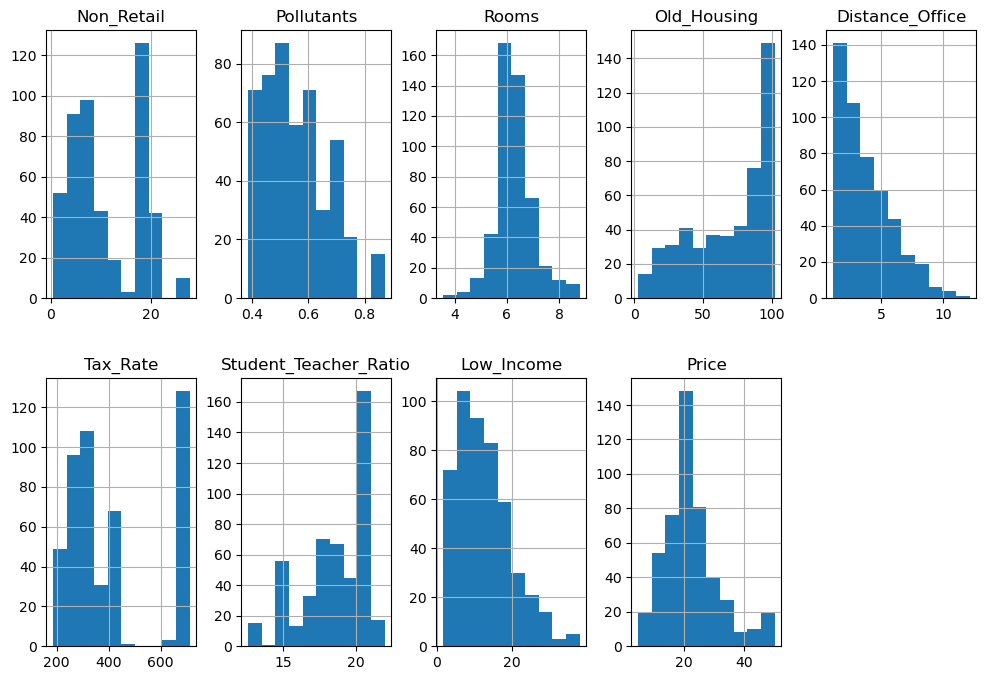

In [12]:
df_numerics = df[["Non_Retail","Pollutants","Rooms","Old_Housing","Distance_Office","Tax_Rate","Student_Teacher_Ratio", "Low_Income", "Price"]]
df_numerics.hist(layout=(2, 5), figsize=(12, 8))
plt.show()

**Non_Retail**: Non-retail land use varies widely across different towns, with a median around 10 and relatively normal distribution around this range. There is a spike in non-retail land usage of around 18.

**Pollutants**: Pollution levels show moderate variation across towns, with most values being concentrated around 0.4 to 0.6, with some abnormalities at more than 0.8. 

**Rooms**: Most houses have about 6 rooms, with some outliers with houses with significantly high or low room counts. Rooms see a relatively normal distribution.

**Old_Housing**: The proportion of old housing varies greatly across towns, showing that theres a wide distribution. There is a spike in frequency for old housings with nearly 100% in percentage, suggesting that a lot of housing estates have old houses.

**Distance_Office**: Distances to employment centres vary moderately, and showing an inverse relationship between distance and frequency of housing estates.

**Tax_Rate**: Tax rates show large variation across towns, with some towns having significantly higher rates. There are two separate distributions of tax rates, with one concentrating from range of 200 to 400, while the other is an outlier with tax rates of more than 600.

**Student_Teacher_Ratio**: Student teacher ratios are quite concentrated around the median, so we can infer that there are similar ratios across most towns. There is a large frequency of towns with ratio of 20. 

**Low_Income**: The proportion of low income residents varies across towns, with some towns having much higher proportions. It shows a relatively normal distribution, but with the mean concentrated at around 10.

**Price**: Housing prices show moderate variation, with a few higher valued outliers, which shows that some towns have significantly more expensive houses. Housing prices has a generally normal distribution based on the histogram.

**c.** Perform bi-variate analysis on the variables. You do not need to present the analysis of every pair of variables; only focus on the pairs you believe are worth investigating and explain. For each pair, describe the relationship between the two variables. Use appropriate statistical methods and/or visualizations.

We use this table to denote the strength of a relationship based on the correlation coefficient.

| r value  | Interpretation         |
| -------- | ---------------------- |
| 0        | No linear relationship |
| ±0.1–0.3 | Weak                   |
| ±0.3–0.5 | Moderate               |
| ±0.5–0.7 | Strong                 |
| ±0.7+    | Very strong            |

### Variables versus Price
First, we analysed the variables that affect the median price of homes (Price).

#### 1. Rooms
Usually, houses with more rooms tend to cost more, so we wanted to see if this rings true for our dataset.

From the scatter plot, as the number of rooms increases, the price also increases.
Additionally, the correlation coefficient also suggests a strong positive linear relationship.

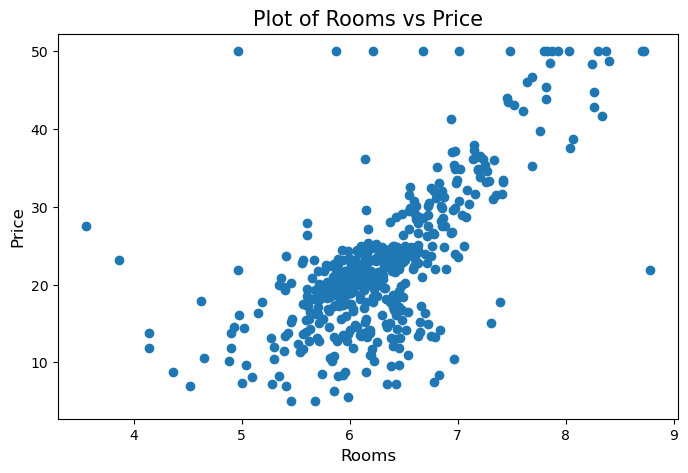

In [13]:
xs = df.Rooms
ys = df.Price

plt.figure(figsize=(8,5))
plt.scatter(xs, ys)
plt.title("Plot of Rooms vs Price", fontsize=15)
plt.xlabel("Rooms", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.show()

In [14]:
corr = np.corrcoef(xs, ys)
print(corr)

[[1.         0.68895429]
 [0.68895429 1.        ]]


#### 2. Low Income
Next, we wanted to investigate if more lower income households correlated to lower housing prices in an area.

From the scatter plot, we can see that residential areas with a higher percentage of lower income households tend to have lower-priced housing. The correlation coefficient also suggests a very strong negative linear relationship.

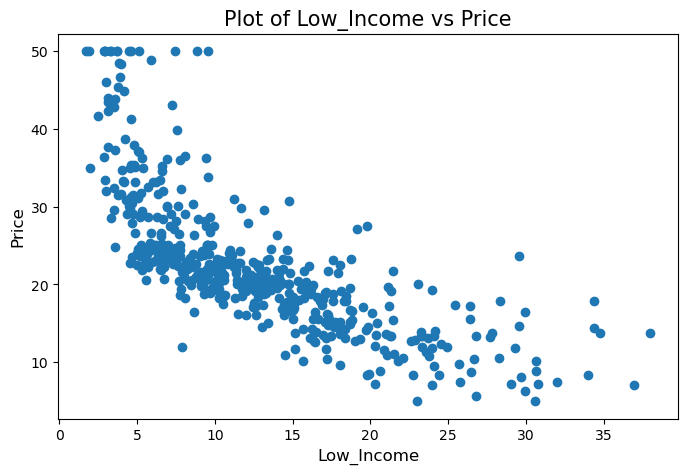

In [15]:
xs = df.Low_Income
ys = df.Price

plt.figure(figsize=(8,5))
plt.scatter(xs, ys)
plt.title("Plot of Low_Income vs Price", fontsize=15)
plt.xlabel("Low_Income", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.show()

In [16]:
corr = np.corrcoef(xs, ys)
print(corr)

[[ 1.         -0.73792378]
 [-0.73792378  1.        ]]


#### 3. Crime Rates
We also wanted to investigate if an area's crime rate would affect its mean price of houses.

From the table, we can see that a higher crime rate leads to a lower mean price of houses. The boxplot also illustrates this. This suggests that crime rate and price have a negative relationship.

Note:
| Encoded Values | Crime Rate |
| -------- | ----------------------|
| 0        | Low|
| 1        | Moderate|
| 2        | High|


In [17]:
df.groupby('Crime_Rate_Encoded')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Crime_Rate_Encoded,,,,,,,,
0,374.0,24.379679,8.430267,5.6,19.40,22.45,27.800,50.0
1,96.0,17.326042,9.231676,6.3,12.25,14.90,19.925,50.0
2,14.0,9.714286,3.063898,5.0,7.75,10.40,10.800,16.3


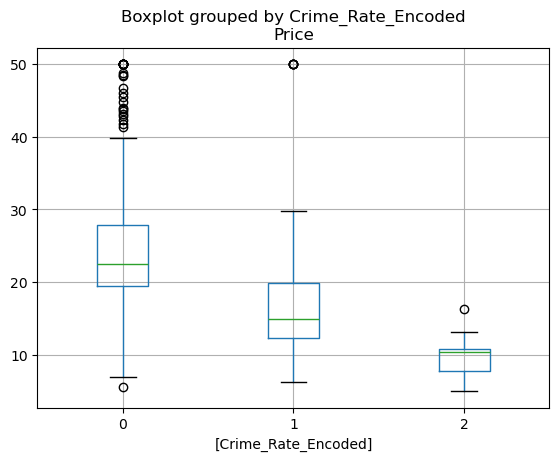

In [18]:
df[['Crime_Rate_Encoded','Price']].boxplot(by='Crime_Rate_Encoded')
plt.show()

#### 4. Pollutants
Lastly, we wanted to see if the degree of pollution would affect housing prices in an area.

From the scatter plot, we can see that more polluted residential areas tended to have lower-priced housing. The correlation coefficient also suggests a moderate negative linear relationship.

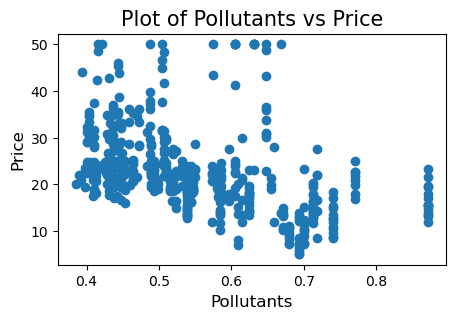

In [19]:
xs = df.Pollutants
ys = df.Price

plt.figure(figsize=(5,3))
plt.scatter(xs, ys)
plt.title("Plot of Pollutants vs Price", fontsize=15)
plt.xlabel("Pollutants", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.show()

In [20]:
corr = np.corrcoef(xs, ys)
print(corr)

[[ 1.         -0.41710631]
 [-0.41710631  1.        ]]


### Variables versus Low Income
We also analysed which variables could affect the percentage of low income households in a residential area.

Note:
| Encoded Values | Crime Rate |
| -------- | ----------------------|
| 0        | Low|
| 1        | Moderate|
| 2        | High|

#### 1. Crime Rate
Both the table and the boxplot strongly suggest that Crime_Rate and Low_Income have a positive relationship. This means that residential areas with a higher percentage of lower income households also tended to have higher crime rates.

In [21]:
df.groupby('Crime_Rate_Encoded')['Low_Income'].describe()

,count,mean,std,min,25%,50%,75%,max
Crime_Rate_Encoded,,,,,,,,
0,374.0,10.674679,5.841621,1.73,6.3600,9.530,13.9950,34.41
1,96.0,18.430625,6.828324,2.96,14.5050,18.090,22.7750,37.97
2,14.0,24.975714,6.199099,14.52,20.9925,23.515,30.0125,36.98


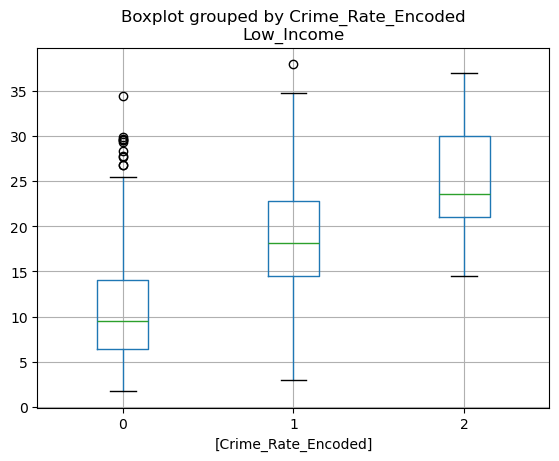

In [22]:
df[['Crime_Rate_Encoded','Low_Income']].boxplot(by='Crime_Rate_Encoded')
plt.show()

#### 2. Pollutants
The scatter plot shows that residential areas with a higher percentage of lower income households also tended to be more polluted. The correlation coefficient also suggests a strong positive linear relationship.

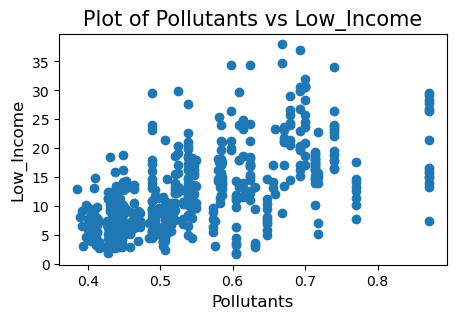

In [23]:
xs = df.Pollutants
ys = df.Low_Income

plt.figure(figsize=(5,3))
plt.scatter(xs, ys)
plt.title("Plot of Pollutants vs Low_Income", fontsize=15)
plt.xlabel("Pollutants", fontsize=12)
plt.ylabel("Low_Income", fontsize=12)
plt.show()

In [24]:
corr = np.corrcoef(xs, ys)
print(corr)

[[1.         0.60175559]
 [0.60175559 1.        ]]


#### 3. Rooms
The scatter plot shows that areas with higher percentage of lower income households also tended to have houses with less rooms. The correlation coefficient also suggests a moderate positive relationship.

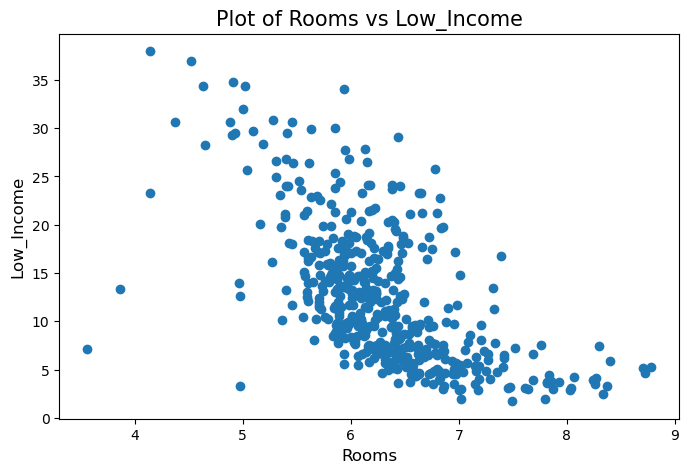

In [25]:
xs = df["Rooms"]
ys = df["Low_Income"]

plt.figure(figsize=(8,5))
plt.scatter(xs, ys)
plt.title("Plot of Rooms vs Low_Income", fontsize=15)
plt.xlabel("Rooms", fontsize=12)
plt.ylabel("Low_Income", fontsize=12)
plt.show()

In [26]:
corr = np.corrcoef(xs, ys)
print(corr)

[[ 1.         -0.61324159]
 [-0.61324159  1.        ]]


#### 4. Student_Teacher_Ratio
The scatter plot suggests a slight correlation between Low_Income and Student_Teacher_Ratio. However, the correlation coefficient is quite low, hence this relationship is rather weak.

This means that the student-teacher ratio may not have that large of an effect on the percentage of low income households in an area, and vice versa.

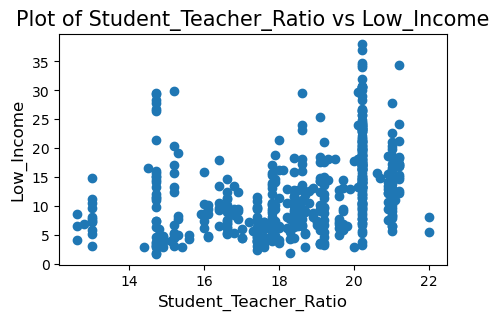

In [27]:
xs = df['Student_Teacher_Ratio']
ys = df.Low_Income

plt.figure(figsize=(5,3))
plt.scatter(xs, ys)
plt.title("Plot of Student_Teacher_Ratio vs Low_Income", fontsize=15)
plt.xlabel('Student_Teacher_Ratio', fontsize=12)
plt.ylabel("Low_Income", fontsize=12)
plt.show()

In [28]:
corr = np.corrcoef(xs, ys)
print(corr)

[[1.         0.36981136]
 [0.36981136 1.        ]]


### Other Relationships

#### 1. Highway_Access versus Pollutants
Both the table and the boxplot shows that greater highway access correlates to a greater number of pollutants. This is likely because more accessible highways lead to more usage of vehicles, which in turn cause more pollution.

Note:
| Encoded Values | Highway Access |
| -------- | ----------------------|
| 0        | Low|
| 1        | Moderate|
| 2        | High|


In [29]:
df.groupby('Highway_Access_Encoded')['Pollutants'].describe()

,count,mean,std,min,25%,50%,75%,max
Highway_Access_Encoded,,,,,,,,
0,75.0,0.464211,0.054519,0.385,0.429,0.449,0.4880,0.581
1,283.0,0.526013,0.105808,0.398,0.439,0.510,0.5485,0.871
2,126.0,0.673540,0.061173,0.532,0.631,0.693,0.7130,0.770


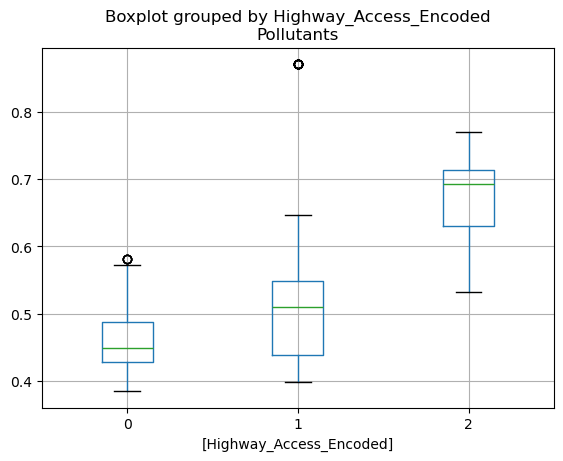

In [30]:
df[['Highway_Access_Encoded','Pollutants']].boxplot(by='Highway_Access_Encoded')
plt.show()

## Part II: Modeling [12% of final grade]

### 1. Problem formulation [15% of Part II]

**a.** Formulate one regression problem and one classification based on the dataset, in **no more than 50 words**.

**Response.** 

**b.** State which problem (regression or classification) you would be investigating and why, in **no more than 20 words**.

**Response.** 

**c.** Clearly specify the dependent variable you are predicting, and its significance, in **no more than 20 words**

**Response.** 

### 2. Model training [30% of Part II]

**a.** Perform feature selection. For each variable, decide if you want to include it as a feature and provide a justification. You may leverage on your analysis in Part I: EDA and/or perform additional analysis.

In [31]:
datatypes = df.dtypes
print(datatypes)

categorical_features = datatypes[datatypes=="object"].index
numerical_features = datatypes[datatypes!="object"].index

ID                            int64
Crime_Rate                   object
Residential_Area             object
Non_Retail                  float64
River                        object
Pollutants                  float64
Rooms                       float64
Old_Housing                 float64
Distance_Office             float64
Highway_Access               object
Tax_Rate                      int64
Student_Teacher_Ratio       float64
Low_Income                  float64
Price                       float64
River_Encoded                 int64
Crime_Rate_Encoded            int64
Highway_Access_Encoded        int64
Residential_Area_Encoded      int64
dtype: object


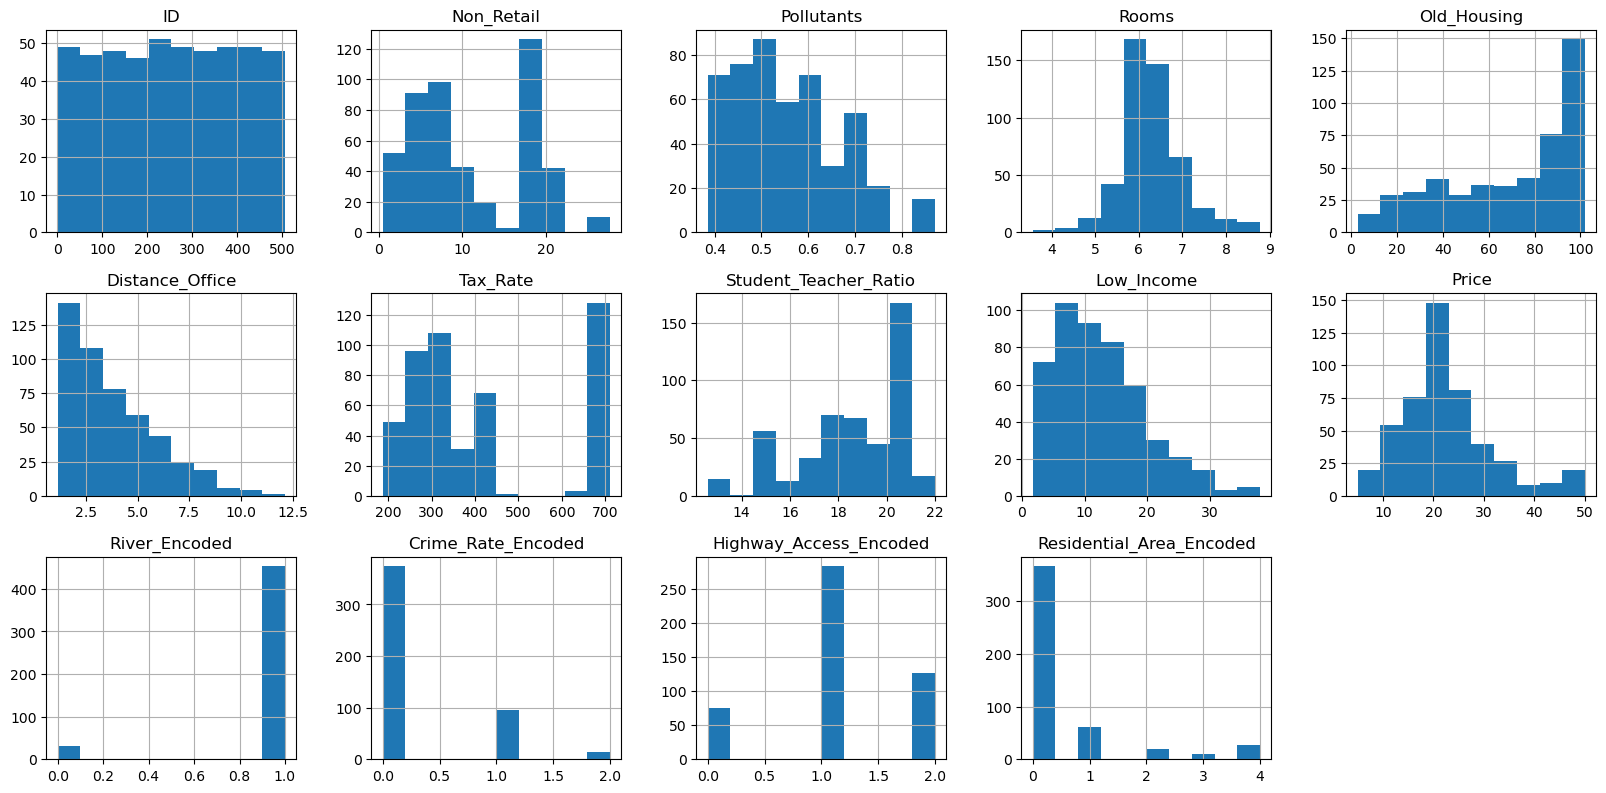

In [32]:
df[numerical_features].hist(layout=(9,5), figsize=(20,30))

plt.show()

In [33]:
features_selected = ["Non_Retail","Pollutants","Rooms","Old_Housing","Distance_Office",\
                     "Tax_Rate","Student_Teacher_Ratio","Low_Income",\
                     "Price"]
df[features_selected].corr()

,Non_Retail,Pollutants,Rooms,Old_Housing,Distance_Office,Tax_Rate,Student_Teacher_Ratio,Low_Income,Price
Non_Retail,1.000000,0.766142,-0.380280,0.637053,-0.700804,0.741251,0.389275,0.608353,-0.474617
Pollutants,0.766142,1.000000,-0.289083,0.725149,-0.769186,0.673851,0.188516,0.601756,-0.417106
Rooms,-0.380280,-0.289083,1.000000,-0.222573,0.184462,-0.295327,-0.360967,-0.613242,0.688954
Old_Housing,0.637053,0.725149,-0.222573,1.000000,-0.744798,0.518167,0.254346,0.591258,-0.355082
Distance_Office,-0.700804,-0.769186,0.184462,-0.744798,1.000000,-0.538883,-0.228417,-0.501676,0.230382
Tax_Rate,0.741251,0.673851,-0.295327,0.518167,-0.538883,1.000000,0.460485,0.561475,-0.464141
Student_Teacher_Ratio,0.389275,0.188516,-0.360967,0.254346,-0.228417,0.460485,1.000000,0.369811,-0.503626
Low_Income,0.608353,0.601756,-0.613242,0.591258,-0.501676,0.561475,0.369811,1.000000,-0.737924
Price,-0.474617,-0.417106,0.688954,-0.355082,0.230382,-0.464141,-0.503626,-0.737924,1.000000


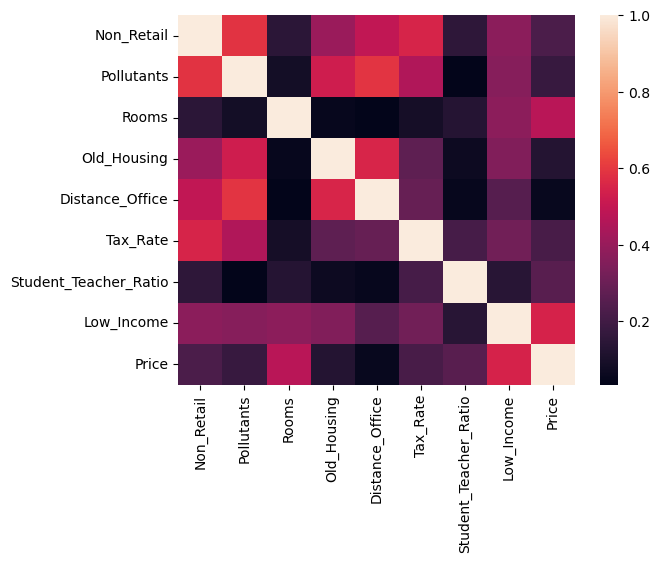

In [34]:
import seaborn as sns
r2 = df[features_selected].corr()**2
sns.heatmap(r2)
plt.show()

In [35]:
def corr_features(df, target, threshold):
    corr_features = []
    for feature in df.columns:
        if feature==target: continue
        x = df[feature]
        y = df[target]
        r2 = np.corrcoef(x,y)[0][1]
        if abs(r2)>threshold:
            corr_features.append(feature)
    return corr_features

features_selected = corr_features(df[features_selected], 'Price', 0.4) # 0.5 removes alot of data 
print(f"updated selected features: {features_selected}")

updated selected features: ['Non_Retail', 'Pollutants', 'Rooms', 'Tax_Rate', 'Student_Teacher_Ratio', 'Low_Income']


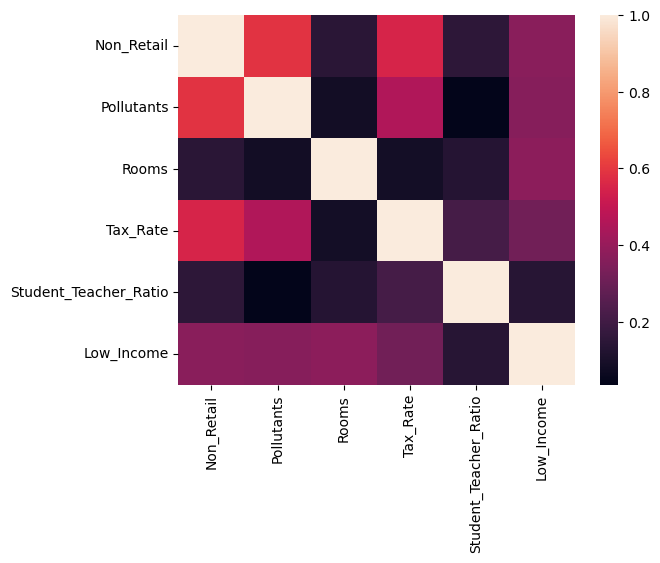

In [36]:
r2 = df[features_selected].corr()**2
sns.heatmap(r2)
plt.show()

In [39]:
def most_corr_feature(df, threshold):
    r2_matrix = abs(df.corr())
    count = r2_matrix[r2_matrix>threshold].count()
    return count.sort_values(ascending=False).index[0]

# return true if all the features are uncorrelated,
# as defined by a threshold

def all_features_uncorr(df, threshold):
    r2_matrix = abs(df.corr())
    n = len(r2_matrix)
    return r2_matrix[r2_matrix>threshold].count().sum()==n

# get a set of uncorrelated features

def get_uncorr_features(df, threshold):
    features = df.columns.tolist()
    while all_features_uncorr(df[features], threshold) == False:
        most_corr_fea = most_corr_feature(df[features], threshold)
        features.remove(most_corr_fea)
    return features

numerical_features_selected = get_uncorr_features(df[features_selected], 0.4)
print(f"Selected numerical features : {numerical_features_selected}")

Selected numerical features : ['Pollutants', 'Rooms', 'Student_Teacher_Ratio']


**Response.** 

**b.** Split the dataset into train and test sets. Describe how you split step by step.

**Response.** 

**c.** State the model(s) you will train, and explain your choice(s), in **no more than 50 words per model**. You only need to
train one model, but if you do train more models, limit yourself to no more than three---Grading is based on the validity and soundness of your model, rather than the quantity.

**Response.** 

**d.** For each model, perform the training, and report the trained parameters and the training scores, if applicable. 

**Response.** 

### 3. Model evaluation and selection [30% of Part II]

**a.** For each model, predict the response variable on the test set.

**Response.** 

**b.** Describe the metric you use to evaluate your model(s). Report the test scores for each model.

**Response.** 

**c.** If you trained more than one model, identify the final model you would choose for the prediction task, and explain your choice, **in no more than 50 words**.

**Response.** 

### 4. Findings and conclusion [20% of Part II]

**a.** Interpret what your model is implying, and summarize any insight you have drawn from the project. Explain if it is consistent with intuition, and if not, provide a plausible justification. Limit your entire response to **50 words**.

**Response.** 

**b.** Share any lesson you have learned from the project, in **no more than 50 words**.

**Response.** 

### 5. Non-technical protocol [5% of Part II]

**a.** Describe the detailed contribution of each team member, including both the tangible (e.g., implementation, testing, writing) and intangible (e.g., generating ideas, planning, leadership) efforts.

**Response.** 

**b.** List any references and sources you have cited.

**Response.** 